# Mock photo-z / selection-function checks: $w(\theta)$

Compare angular correlation of spec mocks in `/global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5` to Quaia data in $0.8 < z < 2.1$.

Mock variants per realization:
- `mock_catalog_quaia_nosel_G20.5.fits` (no selection)
- `mock_catalog_quaia_G20.5_with_zspec.fits` (spectroscopic $z$)
- `mock_catalog_quaia_G20.5.fits` (photo-z selection)


In [1]:
import glob
import os
import time

import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import astropy.cosmology
from astropy.table import Table
from Corrfunc.mocks.DDtheta_mocks import DDtheta_mocks
from Corrfunc.mocks.DDrppi_mocks import DDrppi_mocks
from Corrfunc.utils import convert_3d_counts_to_cf, convert_rp_pi_counts_to_wp

import sys
sys.path.insert(0, '../code')
import correlations

%load_ext autoreload
%autoreload 2


In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rc('text', usetex=False)


In [18]:
# --- configuration (nosel / zspec / photoz order) ---
G_max = 20.5
zmin, zmax = 0.8, 2.1
z_col = 'redshift_quaia'  # data, nosel, photoz
MOCK_Z_COL = {
    'nosel': 'redshift_quaia',
    'zspec': 'redshift_quaia_spec',
    'photoz': 'redshift_quaia',
}
tag_quaia_zclust = '_zmin0.8zmax2.1'
tag_rand_uniform = '_uniform'  # selfunc = all ones

MOCK_BASE = '/global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5'
MOCK_TYPES = {
    'nosel': 'mock_catalog_quaia_nosel_G20.5.fits',
    'zspec': 'mock_catalog_quaia_G20.5_with_zspec.fits',
    'photoz': 'mock_catalog_quaia_G20.5.fits',
}
MOCK_TYPE_LABELS = {
    'nosel': 'photo-$z$, no sel effects',
    'zspec': 'spectroscopic $z$, sel effects',
    'photoz': 'photo-$z$, sel effects',
}
MOCK_COLORS = {
    'nosel': 'forestgreen',
    'zspec': 'royalblue',
    'photoz': 'purple',
}
MOCK_LINESTYLES = {
    'nosel': '-',
    'zspec': '--',
    'photoz': '-.',
}
MOCK_TYPE_KEYS = ['nosel', 'zspec', 'photoz']

N_mocks = 4
nthreads = 16
theta_edges = np.logspace(-2.5, -0.25, 16)
theta = 0.5 * (theta_edges[1:] + theta_edges[:-1])
SKY_SUBSAMPLE = 50000

# wp(rp) binning (Mpc/h)
n_rp_bins = 14
rp_edges = np.logspace(np.log10(1), np.log10(200), n_rp_bins + 1)
rp = 0.5 * (rp_edges[1:] + rp_edges[:-1])
pimax = 100
cosmology = 2
is_comoving_dist = True
wp_rand_seed = 42


## Functions


In [4]:
def sky_arrays(ra, dec):
    return np.asarray(ra, dtype=np.float64), np.asarray(dec, dtype=np.float64)


def z_col_for_mock(mock_key):
    return MOCK_Z_COL[mock_key]


def apply_z_cut(tab, zmin, zmax, z_col=z_col):
    mask = (tab[z_col] > zmin) & (tab[z_col] < zmax)
    return tab[mask]


def load_quaia_data_and_randoms(G_max=G_max, tag_z=tag_quaia_zclust):
    fn_data = f'../data/quaia_G{G_max}{tag_z}.fits'
    fn_rand_sel = f'../data/randoms/random_G{G_max}_zmin{zmin}zmax{zmax}_10x.fits'
    fn_rand_uniform = f'../data/randoms/random_G{G_max}_zmin{zmin}zmax{zmax}_10x{tag_rand_uniform}.fits'
    tab_data = Table.read(fn_data)
    tab_rand_sel = Table.read(fn_rand_sel)
    tab_rand_uniform = Table.read(fn_rand_uniform)
    print(f'Data: {fn_data}  N={len(tab_data)}')
    print(f'Randoms (sel func): {fn_rand_sel}  N={len(tab_rand_sel)}')
    print(f'Randoms (uniform): {fn_rand_uniform}  N={len(tab_rand_uniform)}')
    return tab_data, tab_rand_sel, tab_rand_uniform


def tab_rand_for_mock(mock_key):
    return tab_rand_uniform if mock_key == 'nosel' else tab_rand_sel


def discover_mock_paths(mock_base, mock_filename, n_mocks=None):
    """Find mock*/<mock_filename> under mock_base (one path per realization dir)."""
    if n_mocks is None:
        n_mocks = N_mocks
    pattern = os.path.join(mock_base, 'mock*', mock_filename)
    paths = sorted(glob.glob(pattern))
    if len(paths) == 0:
        raise RuntimeError(f'No mocks found: {pattern}')
    n_avail = len(paths)
    if n_mocks is not None and n_avail < n_mocks:
        print(f'WARNING: requested n_mocks={n_mocks} but only {n_avail} found for {mock_filename}')
    if n_mocks is not None:
        paths = paths[:n_mocks]
    print(f'Using {len(paths)}/{n_avail} available mocks for {mock_filename}')
    for p in paths:
        print(' ', p)
    return paths


def compute_rr_theta(theta_edges, ra_rand, dec_rand, nthreads=nthreads):
    ra_rand, dec_rand = sky_arrays(ra_rand, dec_rand)
    start = time.time()
    RR_theta = DDtheta_mocks(1, nthreads, theta_edges, ra_rand, dec_rand)
    print(f'RR theta time: {time.time() - start:.4f} s')
    return RR_theta


def compute_wtheta_ls(ra, dec, ra_rand, dec_rand, theta_edges, RR_theta,
                      nthreads=nthreads, verbose=True):
    ra, dec = sky_arrays(ra, dec)
    ra_rand, dec_rand = sky_arrays(ra_rand, dec_rand)
    if verbose:
        start = time.time()
    DD_theta = DDtheta_mocks(1, nthreads, theta_edges, ra, dec)
    if verbose:
        print(f'  DD theta time: {time.time() - start:.4f} s')
        start = time.time()
    DR_theta = DDtheta_mocks(0, nthreads, theta_edges, ra, dec,
                             RA2=ra_rand, DEC2=dec_rand)
    if verbose:
        print(f'  DR theta time: {time.time() - start:.4f} s')
    N, N_rand = len(ra), len(ra_rand)
    return convert_3d_counts_to_cf(N, N, N_rand, N_rand,
                                   DD_theta, DR_theta, DR_theta, RR_theta)


def compute_wtheta_data(tab_data, tab_rand, theta_edges, RR_theta, nthreads=nthreads):
    return compute_wtheta_ls(tab_data['ra'], tab_data['dec'],
                             tab_rand['ra'], tab_rand['dec'],
                             theta_edges, RR_theta, nthreads=nthreads)


def compute_mock_ensemble_wtheta(mock_paths, tab_rand, theta_edges, RR_theta,
                                 mock_key, zmin=zmin, zmax=zmax, nthreads=nthreads):
    z_col_mock = z_col_for_mock(mock_key)
    ra_rand, dec_rand = tab_rand['ra'], tab_rand['dec']
    wtheta_list = []
    for i, path in enumerate(mock_paths):
        tab = apply_z_cut(Table.read(path), zmin, zmax, z_col=z_col_mock)
        print(f'Mock {i+1}/{len(mock_paths)}: {path} ({z_col_mock}) -> N(zcut)={len(tab)}')
        wtheta_list.append(
            compute_wtheta_ls(tab['ra'], tab['dec'], ra_rand, dec_rand,
                              theta_edges, RR_theta, nthreads=nthreads))
    return np.array(wtheta_list)


def summarize_ensemble(arr):
    """Mean and 16/84 percentiles over mock realizations."""
    return {
        'mean': np.mean(arr, axis=0),
        'p16': np.percentile(arr, 16, axis=0),
        'p84': np.percentile(arr, 84, axis=0),
    }


def summarize_wtheta_ensemble(wtheta_mocks):
    return summarize_ensemble(wtheta_mocks)
    return {
        'mean': np.mean(wtheta_mocks, axis=0),
        'p16': np.percentile(wtheta_mocks, 16, axis=0),
        'p84': np.percentile(wtheta_mocks, 84, axis=0),
    }

def comoving_dist_mpc_h(z, cosmo=None):
    """Comoving distance in Mpc/h for Corrfunc (is_comoving_dist=True)."""
    if cosmo is None:
        cosmo = astropy.cosmology.Planck18
    return cosmo.comoving_distance(np.asarray(z)).value * cosmo.h


def setup_wp_uniform_distances(tab_rand, zmin=zmin, zmax=zmax, seed=wp_rand_seed, cosmo=None):
    """Uniform z in [zmin, zmax] for nosel (uniform-sky randoms)."""
    if cosmo is None:
        cosmo = astropy.cosmology.Planck18
    rng = np.random.default_rng(seed)
    z_rand = rng.uniform(zmin, zmax, size=len(tab_rand))
    return cosmo, comoving_dist_mpc_h(z_rand, cosmo)


def setup_wp_random_distances(tab_data, tab_rand, z_col_data=z_col, seed=wp_rand_seed,
                              cosmo=None):
    """Shuffle data redshifts onto randoms (photo-z / zspec mocks + data)."""
    if cosmo is None:
        cosmo = astropy.cosmology.Planck18
    rng = np.random.default_rng(seed)
    z_rand_shared = rng.choice(tab_data[z_col_data], size=len(tab_rand), replace=True)
    dist_rand_shared = comoving_dist_mpc_h(z_rand_shared, cosmo)
    return cosmo, dist_rand_shared


def compute_rr_rp(rp_edges, pimax, ra_rand, dec_rand, dist_rand,
                  cosmology=cosmology, nthreads=nthreads,
                  is_comoving_dist=is_comoving_dist):
    ra_rand, dec_rand = sky_arrays(ra_rand, dec_rand)
    dist_rand = np.asarray(dist_rand, dtype=np.float64)
    start = time.time()
    RR_rp = DDrppi_mocks(1, cosmology, nthreads, pimax, rp_edges,
                         ra_rand, dec_rand, dist_rand,
                         is_comoving_dist=is_comoving_dist)
    print(f'RR rp time: {time.time() - start:.4f} s')
    return RR_rp


def compute_wp_ls(ra, dec, dist, ra_rand, dec_rand, dist_rand, rp_edges, pimax, RR_rp,
                  cosmology=cosmology, nthreads=nthreads, verbose=True,
                  is_comoving_dist=is_comoving_dist):
    """Landy-Szalay wp(rp) reusing precomputed RR(rp, pi)."""
    ra, dec = sky_arrays(ra, dec)
    ra_rand, dec_rand = sky_arrays(ra_rand, dec_rand)
    dist = np.asarray(dist, dtype=np.float64)
    dist_rand = np.asarray(dist_rand, dtype=np.float64)
    n_rpbins = len(rp_edges) - 1
    if verbose:
        start = time.time()
    DD_rp = DDrppi_mocks(1, cosmology, nthreads, pimax, rp_edges, ra, dec, dist,
                         is_comoving_dist=is_comoving_dist)
    if verbose:
        print(f'  DD rp time: {time.time() - start:.4f} s')
        start = time.time()
    DR_rp = DDrppi_mocks(0, cosmology, nthreads, pimax, rp_edges, ra, dec, dist,
                         RA2=ra_rand, DEC2=dec_rand, CZ2=dist_rand,
                         is_comoving_dist=is_comoving_dist)
    if verbose:
        print(f'  DR rp time: {time.time() - start:.4f} s')
    N, N_rand = len(ra), len(ra_rand)
    return convert_rp_pi_counts_to_wp(N, N, N_rand, N_rand,
                                      DD_rp, DR_rp, DR_rp, RR_rp,
                                      n_rpbins, pimax)


def compute_wp_data(tab_data, tab_rand, dist_rand_shared, rp_edges, pimax, RR_rp,
                    z_col_data=z_col, cosmo=None, nthreads=nthreads):
    if cosmo is None:
        cosmo = astropy.cosmology.Planck18
    dist_data = comoving_dist_mpc_h(tab_data[z_col_data], cosmo)
    return compute_wp_ls(tab_data['ra'], tab_data['dec'], dist_data,
                         tab_rand['ra'], tab_rand['dec'], dist_rand_shared,
                         rp_edges, pimax, RR_rp, nthreads=nthreads)


def compute_mock_ensemble_wp(mock_paths, tab_rand, dist_rand_shared, rp_edges, pimax, RR_rp,
                             mock_key, zmin=zmin, zmax=zmax, cosmo=None, nthreads=nthreads):
    z_col_mock = z_col_for_mock(mock_key)
    if cosmo is None:
        cosmo = astropy.cosmology.Planck18
    ra_rand, dec_rand = tab_rand['ra'], tab_rand['dec']
    wp_list = []
    for i, path in enumerate(mock_paths):
        tab = apply_z_cut(Table.read(path), zmin, zmax, z_col=z_col_mock)
        dist = comoving_dist_mpc_h(tab[z_col_mock], cosmo)
        print(f'Mock {i+1}/{len(mock_paths)}: {path} ({z_col_mock}) -> N(zcut)={len(tab)}')
        wp_list.append(
            compute_wp_ls(tab['ra'], tab['dec'], dist, ra_rand, dec_rand, dist_rand_shared,
                          rp_edges, pimax, RR_rp, nthreads=nthreads))
    return np.array(wp_list)


## Load data and shared randoms


In [5]:
tab_data, tab_rand_sel, tab_rand_uniform = load_quaia_data_and_randoms()
ra_rand_sel, dec_rand_sel = tab_rand_sel['ra'], tab_rand_sel['dec']
ra_rand_uniform, dec_rand_uniform = tab_rand_uniform['ra'], tab_rand_uniform['dec']
print('theta_edges:', theta_edges)


Data: ../data/quaia_G20.5_zmin0.8zmax2.1.fits  N=814561
Randoms (sel func): ../data/randoms/random_G20.5_zmin0.8zmax2.1_10x.fits  N=8141884
Randoms (uniform): ../data/randoms/random_G20.5_zmin0.8zmax2.1_10x_uniform.fits  N=8145610
theta_edges: [0.00316228 0.00446684 0.00630957 0.00891251 0.01258925 0.01778279
 0.02511886 0.03548134 0.05011872 0.07079458 0.1        0.14125375
 0.19952623 0.28183829 0.39810717 0.56234133]


## Visualizations


In [6]:
# viz: one realization per type (ensemble uses N_mocks below)
viz_tabs = {'data': tab_data}
for mock_key in MOCK_TYPE_KEYS:
    path = discover_mock_paths(MOCK_BASE, MOCK_TYPES[mock_key], n_mocks=1)[0]
    zc = z_col_for_mock(mock_key)
    viz_tabs[mock_key] = apply_z_cut(Table.read(path), zmin, zmax, z_col=zc)
    print(f'{mock_key} ({zc}): N(z-cut)={len(viz_tabs[mock_key])}')


Using 1/1 available mocks for mock_catalog_quaia_nosel_G20.5.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_nosel_G20.5.fits
nosel (redshift_quaia): N(z-cut)=814564
Using 1/1 available mocks for mock_catalog_quaia_G20.5_with_zspec.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5_with_zspec.fits
zspec (redshift_quaia_spec): N(z-cut)=817074
Using 1/1 available mocks for mock_catalog_quaia_G20.5.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5.fits
photoz (redshift_quaia): N(z-cut)=814540


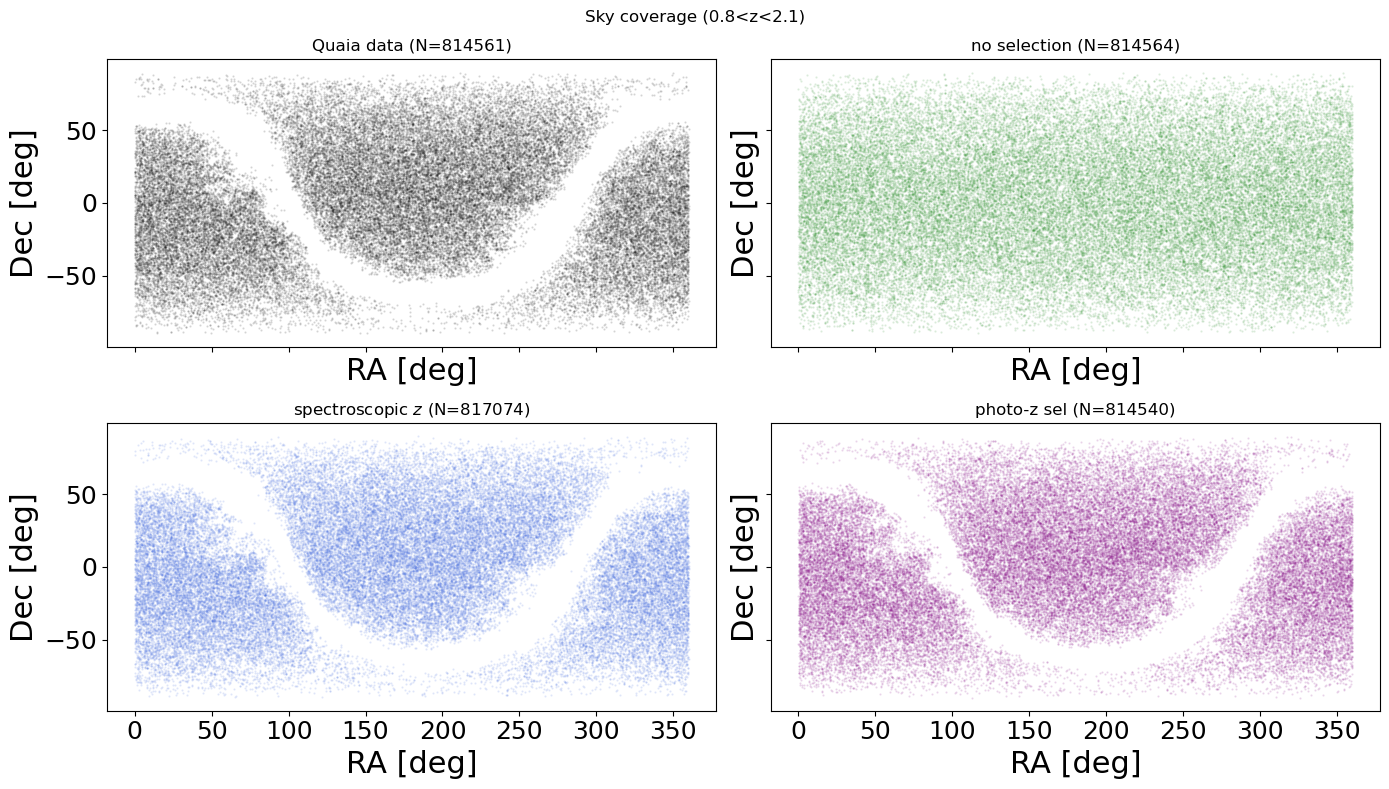

In [7]:
def subsample_tab(tab, n_max=SKY_SUBSAMPLE, seed=42):
    if len(tab) <= n_max:
        return tab
    rng = np.random.default_rng(seed)
    return tab[rng.choice(len(tab), size=n_max, replace=False)]

panels = [('data', 'Quaia data', 'black')]
panels += [(k, MOCK_TYPE_LABELS[k], MOCK_COLORS[k]) for k in MOCK_TYPE_KEYS]
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
for ax, (key, label, color) in zip(axes.flat, panels):
    t = subsample_tab(viz_tabs[key])
    ax.scatter(t['ra'], t['dec'], s=0.3, alpha=0.15, c=color, rasterized=True)
    ax.set_title(f'{label} (N={len(viz_tabs[key])})')
    ax.set_xlabel('RA [deg]'); ax.set_ylabel('Dec [deg]')
fig.suptitle(f'Sky coverage ({zmin}<z<{zmax})')
fig.tight_layout(); plt.show()


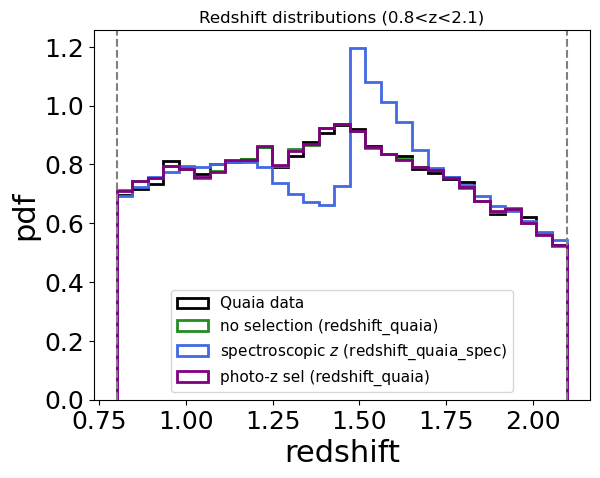

In [8]:
z_bins = np.linspace(zmin, zmax, 30)

fig, ax = plt.subplots()
ax.hist(tab_data[z_col], bins=z_bins, histtype='step', lw=2, color='black',
        density=True, label='Quaia data')
for mock_key in MOCK_TYPE_KEYS:
    zc = z_col_for_mock(mock_key)
    ax.hist(viz_tabs[mock_key][zc], bins=z_bins, histtype='step', lw=2,
            color=MOCK_COLORS[mock_key], density=True,
            label=f"{MOCK_TYPE_LABELS[mock_key]} ({zc})")
ax.axvline(zmin, color='grey', ls='--'); ax.axvline(zmax, color='grey', ls='--')
ax.set_xlabel('redshift'); ax.set_ylabel('pdf'); ax.legend(fontsize=11)
ax.set_title(f'Redshift distributions ({zmin}<z<{zmax})')
plt.show()


In [9]:
RR_theta_sel = compute_rr_theta(theta_edges, ra_rand_sel, dec_rand_sel, nthreads=nthreads)
RR_theta_uniform = compute_rr_theta(theta_edges, ra_rand_uniform, dec_rand_uniform, nthreads=nthreads)


[Warning] The CPU supports AVX2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports AVX but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.2 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSE4.1 but the compiler does not.  Can you try another compiler?
[Warning] The CPU supports SSSE3 but the compiler does not.  Can you try another compiler?


RR theta time: 44.2569 s
RR theta time: 34.7061 s


In [10]:
wtheta_data = compute_wtheta_data(tab_data, tab_rand_sel, theta_edges, RR_theta_sel, nthreads=nthreads)
print('N data =', len(tab_data))


  DD theta time: 0.6976 s
  DR theta time: 11.6623 s
N data = 814561


## Mock ensembles ($w(\theta)$)


In [11]:
results = {}
N_mocks_used = {}
for mock_key in MOCK_TYPE_KEYS:
    print(f'\n=== {mock_key} (z col: {z_col_for_mock(mock_key)}) ===')
    tab_rand = tab_rand_for_mock(mock_key)
    RR_theta = RR_theta_uniform if mock_key == 'nosel' else RR_theta_sel
    paths = discover_mock_paths(MOCK_BASE, MOCK_TYPES[mock_key], n_mocks=N_mocks)
    N_mocks_used[mock_key] = len(paths)
    wtheta_mocks = compute_mock_ensemble_wtheta(
        paths, tab_rand, theta_edges, RR_theta, mock_key=mock_key)
    results[mock_key] = {'paths': paths, 'wtheta_mocks': wtheta_mocks,
                       **summarize_ensemble(wtheta_mocks)}
print('N_mocks requested:', N_mocks)
print('N_mocks used per type:', N_mocks_used)



=== nosel (z col: redshift_quaia) ===
Using 1/1 available mocks for mock_catalog_quaia_nosel_G20.5.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_nosel_G20.5.fits
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_nosel_G20.5.fits (redshift_quaia) -> N(zcut)=814564


  DD theta time: 0.6103 s
  DR theta time: 9.6631 s

=== zspec (z col: redshift_quaia_spec) ===
Using 1/1 available mocks for mock_catalog_quaia_G20.5_with_zspec.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5_with_zspec.fits
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5_with_zspec.fits (redshift_quaia_spec) -> N(zcut)=817074
  DD theta time: 0.7235 s
  DR theta time: 11.7242 s

=== photoz (z col: redshift_quaia) ===
Using 1/1 available mocks for mock_catalog_quaia_G20.5.fits
  /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5.fits
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5.fits (redshift_quaia) -> N(zcut)=814540
  DD theta time: 0.7212 s
  DR theta time: 11.7270 s
N_mocks requested: 4
N_mocks used per type: {'nosel': 1, 'zspec': 1, 'photoz': 1}


## Plot: mock means vs data (all 3 types)


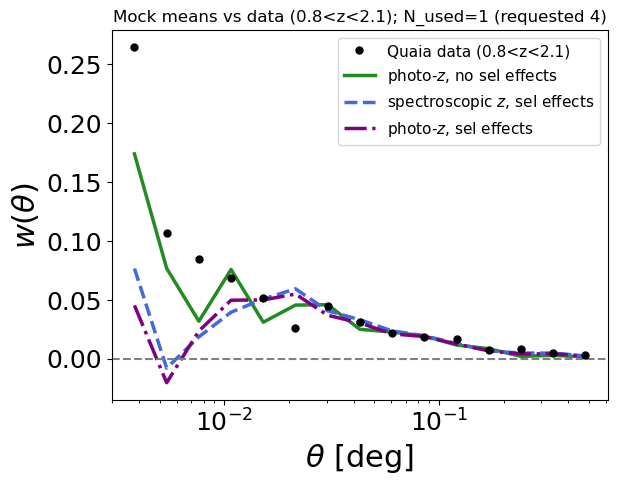

In [20]:
fig, ax = plt.subplots()
ax.plot(theta, wtheta_data, color='black', marker='o', linestyle='none', markersize=5,
        label=f'Quaia data ({zmin}<z<{zmax})', zorder=10)
for mock_key in MOCK_TYPE_KEYS:
    ax.plot(theta, results[mock_key]['mean'], color=MOCK_COLORS[mock_key],
            linestyle=MOCK_LINESTYLES[mock_key], lw=2.5,
            label=MOCK_TYPE_LABELS[mock_key])
ax.set_xscale('log'); ax.axhline(0, color='grey', ls='--')
ax.set_xlabel(r'$\theta$ [deg]'); ax.set_ylabel(r'$w(\theta)$')
ax.legend(fontsize=11)
n_used = min(N_mocks_used.values()) if N_mocks_used else 0
ax.set_title(f'Mock means vs data ({zmin}<z<{zmax}); N_used={n_used} (requested {N_mocks})')
plt.show()


## $w_p(r_p)$


In [13]:
cosmo, dist_rand_shared = setup_wp_random_distances(tab_data, tab_rand_sel)
_, dist_rand_uniform = setup_wp_uniform_distances(tab_rand_uniform, cosmo=cosmo)
ra_rand_wp_sel, dec_rand_wp_sel = tab_rand_sel['ra'], tab_rand_sel['dec']
ra_rand_wp_uniform, dec_rand_wp_uniform = tab_rand_uniform['ra'], tab_rand_uniform['dec']
print('rp_edges:', rp_edges)


rp_edges: [  1.           1.46002162   2.13166312   3.11227423   4.54398764
   6.63432018   9.68625086  14.14213562  20.64782369  30.1462689
  44.01420421  64.26168951  93.82345571 136.98427334 200.        ]


In [14]:
RR_rp_sel = compute_rr_rp(rp_edges, pimax, ra_rand_wp_sel, dec_rand_wp_sel, dist_rand_shared)
RR_rp_uniform = compute_rr_rp(rp_edges, pimax, ra_rand_wp_uniform, dec_rand_wp_uniform, dist_rand_uniform)


RR rp time: 334.3921 s
RR rp time: 260.7885 s


In [15]:
wp_data = compute_wp_data(tab_data, tab_rand_sel, dist_rand_shared, rp_edges, pimax, RR_rp_sel, cosmo=cosmo)
print('N data =', len(tab_data))


  DD rp time: 4.2477 s


  DR rp time: 79.0273 s
N data = 814561


## Mock ensembles ($w_p$)


In [16]:
wp_results = {}
for mock_key in MOCK_TYPE_KEYS:
    print(f'\n=== wp {mock_key} (z col: {z_col_for_mock(mock_key)}) ===')
    tab_rand = tab_rand_for_mock(mock_key)
    RR_rp = RR_rp_uniform if mock_key == 'nosel' else RR_rp_sel
    dist_rand = dist_rand_uniform if mock_key == 'nosel' else dist_rand_shared
    paths = results[mock_key]['paths']
    wp_mocks = compute_mock_ensemble_wp(
        paths, tab_rand, dist_rand, rp_edges, pimax, RR_rp,
        mock_key=mock_key, cosmo=cosmo)
    wp_results[mock_key] = {'paths': paths, 'wp_mocks': wp_mocks,
                            **summarize_ensemble(wp_mocks)}



=== wp nosel (z col: redshift_quaia) ===
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_nosel_G20.5.fits (redshift_quaia) -> N(zcut)=814564
  DD rp time: 3.5652 s
  DR rp time: 61.8195 s

=== wp zspec (z col: redshift_quaia_spec) ===
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5_with_zspec.fits (redshift_quaia_spec) -> N(zcut)=817074
  DD rp time: 4.4263 s
  DR rp time: 81.5866 s

=== wp photoz (z col: redshift_quaia) ===
Mock 1/1: /global/cfs/cdirs/desi/users/fsin/quaia/mocks_spec/G20.5/mock51/mock_catalog_quaia_G20.5.fits (redshift_quaia) -> N(zcut)=814540
  DD rp time: 4.5872 s
  DR rp time: 81.1713 s


## Plot: $w_p(r_p)$ mock means vs data


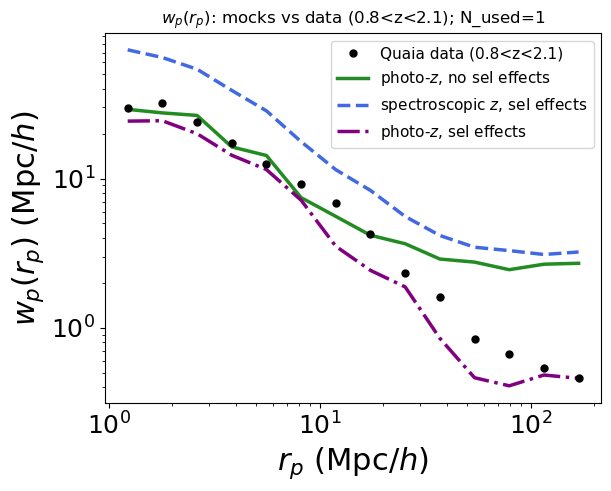

In [19]:
fig, ax = plt.subplots()
ax.plot(rp, wp_data, color='black', marker='o', linestyle='none', markersize=5,
        label=f'Quaia data ({zmin}<z<{zmax})', zorder=10)
for mock_key in MOCK_TYPE_KEYS:
    ax.plot(rp, wp_results[mock_key]['mean'], color=MOCK_COLORS[mock_key],
            linestyle=MOCK_LINESTYLES[mock_key], lw=2.5,
            label=MOCK_TYPE_LABELS[mock_key])
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'$r_p$ (Mpc/$h$)'); ax.set_ylabel(r'$w_p(r_p)$ (Mpc/$h$)')
ax.legend(fontsize=11)
n_used = min(N_mocks_used.values()) if N_mocks_used else 0
ax.set_title(f'$w_p(r_p)$: mocks vs data ({zmin}<z<{zmax}); N_used={n_used}')
plt.show()
